Phase 1:Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Phase 2:Load and explore the dataset

1.Load the dataset

In [2]:
gold_data=pd.read_csv('/content/archive.zip')

2.Display first five rows

In [3]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


3.Display last five rows

In [4]:
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


4.Find the Shape of the Dataset

In [6]:
gold_data.shape

(2290, 6)

5.Display Column Names

In [7]:
gold_data.columns

Index(['Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD'], dtype='object')

6.Check Data Types

In [8]:
gold_data.dtypes

,0
Date,object
SPX,float64
GLD,float64
USO,float64
SLV,float64
EUR/USD,float64


7.Dataset Information

In [9]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


8.Check Missing Values

In [10]:
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


9.Check Duplicate Rows

In [12]:
gold_data.duplicated().sum()

np.int64(0)

10.Statistical Summary

In [13]:
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Phase 3: Exploratory Data Analysis (EDA)

1.Correlation Analysis

In [14]:
correlation = gold_data.drop(columns='Date').corr()
correlation

,SPX,GLD,USO,SLV,EUR/USD
SPX,1.000000,0.049345,-0.591573,-0.274055,-0.672017
GLD,0.049345,1.000000,-0.186360,0.866632,-0.024375
USO,-0.591573,-0.186360,1.000000,0.167547,0.829317
SLV,-0.274055,0.866632,0.167547,1.000000,0.321631
EUR/USD,-0.672017,-0.024375,0.829317,0.321631,1.000000


2.Correlation Heatmap

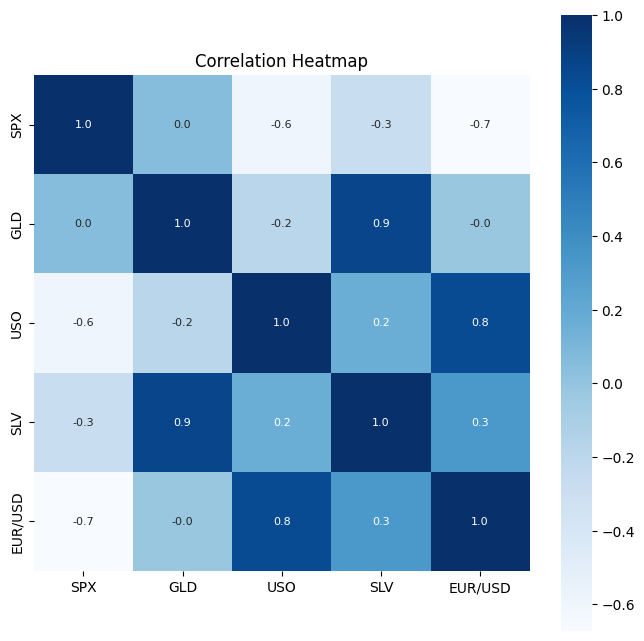

In [15]:
plt.figure(figsize=(8, 8))
sns.heatmap(correlation,
            cbar=True,
            square=True,
            fmt='.1f',
            annot=True,
            annot_kws={'size': 8},
            cmap='Blues')

plt.title("Correlation Heatmap")
plt.show()

3.Distribution of Gold Price

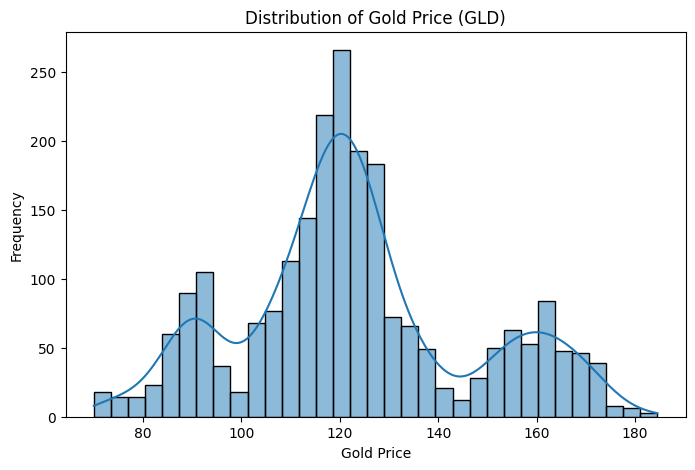

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(gold_data['GLD'], kde=True)
plt.title("Distribution of Gold Price (GLD)")
plt.xlabel("Gold Price")
plt.ylabel("Frequency")
plt.show()

Phase 4: Feature Selection and Train-Test Split

1.Feature Selection

In [17]:
X = gold_data.drop(columns=['Date', 'GLD'], axis=1)
Y = gold_data['GLD']

2.Display Features and Target

In [18]:
X.head()

,SPX,USO,SLV,EUR/USD
0,1447.160034,78.470001,15.180,1.471692
1,1447.160034,78.370003,15.285,1.474491
2,1411.630005,77.309998,15.167,1.475492
3,1416.180054,75.500000,15.053,1.468299
4,1390.189941,76.059998,15.590,1.557099


In [19]:
Y.head()

,GLD
0,84.860001
1,85.570000
2,85.129997
3,84.769997
4,86.779999


4.Split the Dataset

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

4. Check the Shapes

In [21]:
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Target Shape   :", Y_train.shape)
print("Testing Target Shape    :", Y_test.shape)

Training Features Shape : (1832, 4)
Testing Features Shape  : (458, 4)
Training Target Shape   : (1832,)
Testing Target Shape    : (458,)


Phase 5: Model Training (Random Forest Regressor)

1. Build the Machine Learning Model

In [22]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

2.Train the Model

In [23]:
regressor.fit(X_train, Y_train)

RandomForestRegressor(random_state=42)

3.Verify Model Training

In [24]:
print(regressor)

RandomForestRegressor(random_state=42)


Phase 6: Model Prediction and Performance Evalu

1.Make Predictions

In [25]:
Y_pred = regressor.predict(X_test)
print(Y_pred[:10])

[122.46679941 130.28880316 127.70419932  96.69889736 118.97240056
 114.50079901 124.67450149 117.84389959 108.10790103  98.21069968]


2.Evaluate the Model

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.2356137487336276
Mean Squared Error (MSE): 5.469544524374734
Root Mean Squared Error (RMSE): 2.3387057370209563
R² Score: 0.9900245384549384


3.Compare Actual vs Predicted Values

In [27]:
comparison = pd.DataFrame({
    "Actual Price": Y_test.values,
    "Predicted Price": Y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,122.320000,122.466799
1,129.899994,130.288803
2,126.980003,127.704199
3,96.500000,96.698897
4,117.580002,118.972401
5,115.000000,114.500799
6,125.440002,124.674501
7,116.930000,117.843900
8,108.220001,108.107901
9,98.830002,98.210700


4.Visualize Actual vs Predicted Prices

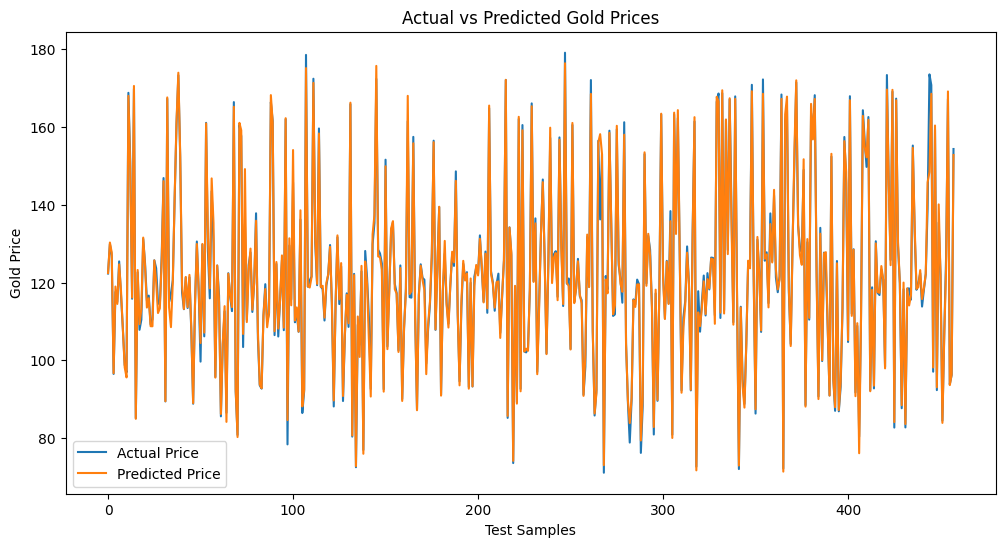

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(Y_test.values, label='Actual Price')
plt.plot(Y_pred, label='Predicted Price')

plt.title("Actual vs Predicted Gold Prices")
plt.xlabel("Test Samples")
plt.ylabel("Gold Price")
plt.legend()

plt.show()